Homework 2, Part 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [3]:
# ====================================================================
# DATASET 1: RETAIL SALES (for Regression & ETS)
# ====================================================================
print("\n" + "=" * 70)
print("DATASET 1: Monthly Retail Sales")
print("=" * 70)

dates = pd.date_range('2021-01-01', '2024-12-31', freq='MS')
n_months = len(dates)
t = np.arange(n_months)

trend = 1000 + 15*t
yearly_seasonal = 300*np.sin(2*np.pi*t/12) + 200*np.cos(2*np.pi*t/12)

holiday_effect = np.zeros(n_months)
for year in range(4):
    nov_idx = year*12 + 10
    dec_idx = year*12 + 11
    if nov_idx < n_months:
        holiday_effect[nov_idx] = 400
    if dec_idx < n_months:
        holiday_effect[dec_idx] = 600

noise = np.random.normal(0, 80, n_months)
sales = trend + yearly_seasonal + holiday_effect + noise
sales = np.maximum(sales, 0)

df_sales = pd.DataFrame({
    'Date': dates,
    'Sales': sales,
    'Month': dates.month,
    'Year': dates.year,
    'Time': t
}).set_index('Date')

print(f"Date range: {df_sales.index[0].date()} to {df_sales.index[-1].date()}")
print(f"Number of months: {len(df_sales)}")
print("\nSales Statistics:")
print(df_sales['Sales'].describe())


DATASET 1: Monthly Retail Sales
Date range: 2021-01-01 to 2024-12-01
Number of months: 48

Sales Statistics:
count      48.000000
mean     1419.409544
std       352.878551
min       722.634428
25%      1196.284168
50%      1393.908200
75%      1710.667034
max      2412.774859
Name: Sales, dtype: float64


In [4]:
# ====================================================================
# PART A: REGRESSION AND ETS MODELS
# ====================================================================
print("\n" + "=" * 70)
print("PART A: REGRESSION AND ETS MODELS")
print("=" * 70)


PART A: REGRESSION AND ETS MODELS



----------------------------------------------------------------------
A1: Exploratory Visualization
----------------------------------------------------------------------


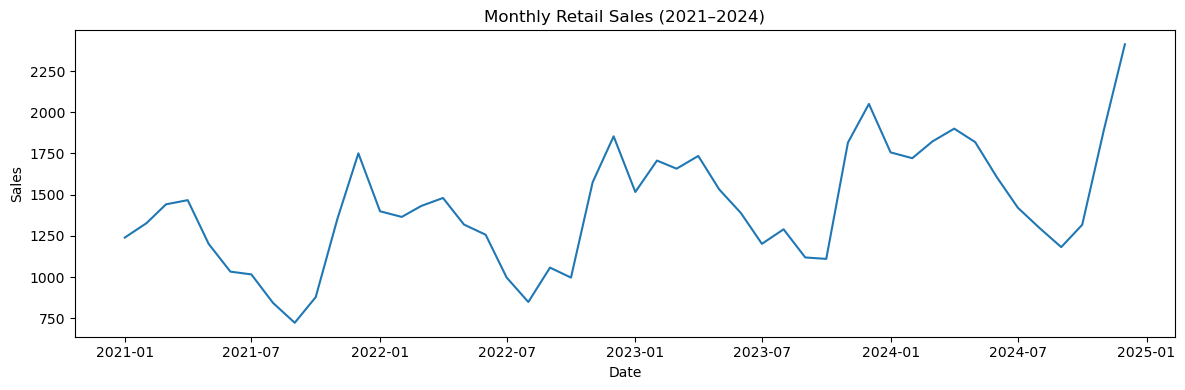

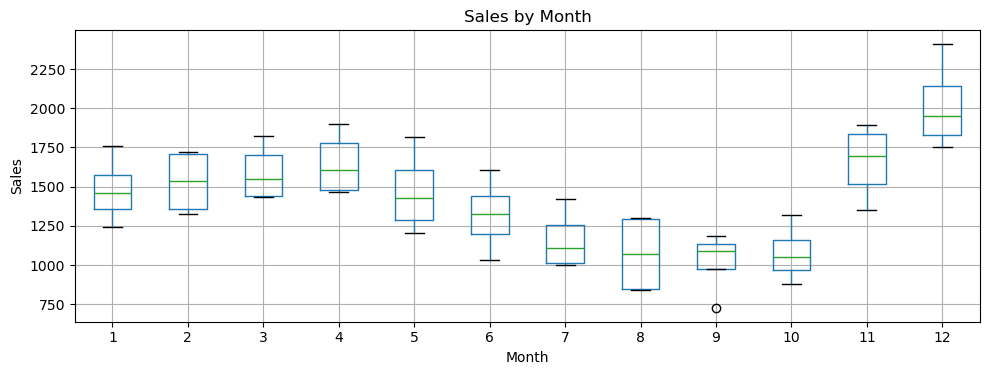

Highest average sales occur in month 12 (holiday season).


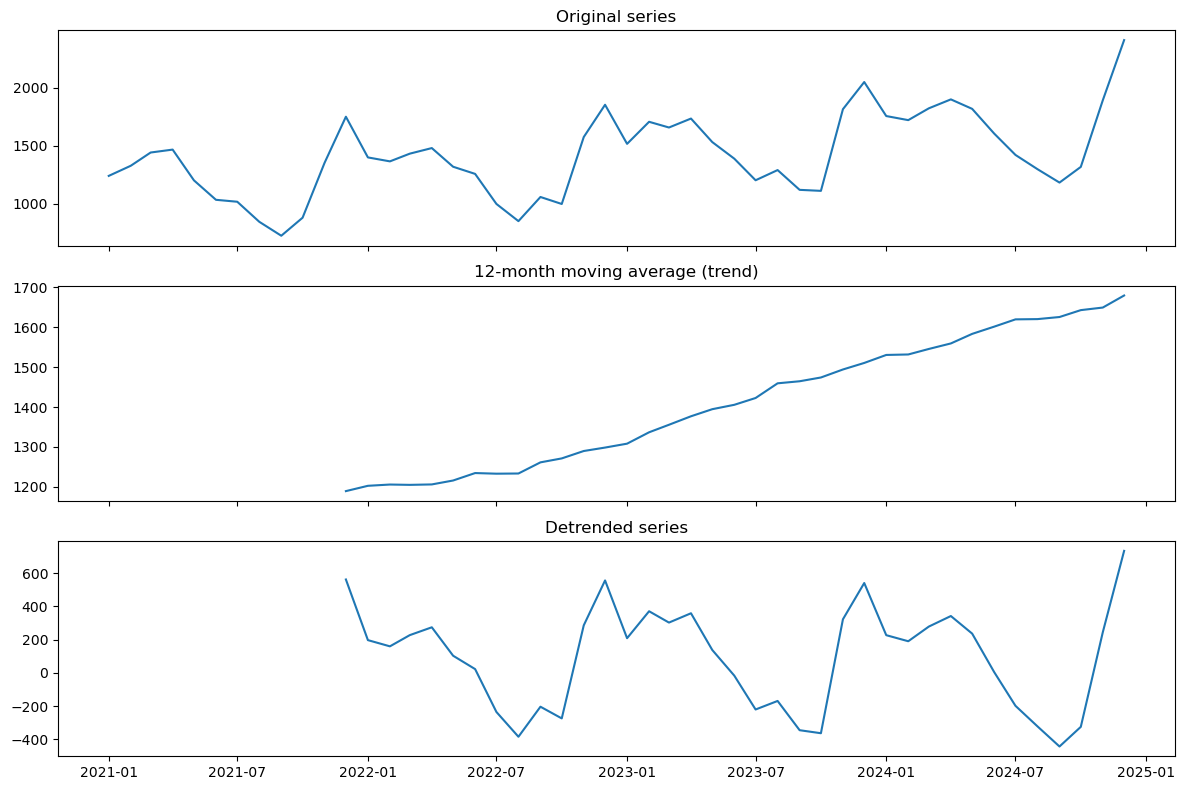

In [5]:
# --------------------------------------------------------------------
# A1: Exploratory Visualization
# --------------------------------------------------------------------
print("\n" + "-" * 70)
print("A1: Exploratory Visualization")
print("-" * 70)

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(df_sales.index, df_sales['Sales'])
ax.set_title("Monthly Retail Sales (2021–2024)")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
plt.tight_layout()
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(10,4))
df_sales.boxplot(column='Sales', by='Month', ax=ax)
ax.set_title("Sales by Month")
plt.suptitle("")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
plt.tight_layout()
plt.show()
plt.close(fig)

monthly_avg = df_sales.groupby('Month')['Sales'].mean()
print("Highest average sales occur in month", int(monthly_avg.idxmax()), "(holiday season).")

trend_ma12 = df_sales['Sales'].rolling(12).mean()
detrended = df_sales['Sales'] - trend_ma12

fig, ax = plt.subplots(3,1,figsize=(12,8),sharex=True)
ax[0].plot(df_sales.index, df_sales['Sales'])
ax[0].set_title("Original series")
ax[1].plot(df_sales.index, trend_ma12)
ax[1].set_title("12-month moving average (trend)")
ax[2].plot(df_sales.index, detrended)
ax[2].set_title("Detrended series")
plt.tight_layout()
plt.show()
plt.close(fig)

In [6]:
# --------------------------------------------------------------------
# A2: Regression Forecasting
# --------------------------------------------------------------------
print("\n" + "-" * 70)
print("A2: Regression Forecasting")
print("-" * 70)

month_dummies = pd.get_dummies(df_sales['Month'], drop_first=True, dtype=float)
X = pd.concat([df_sales['Time'].astype(float), month_dummies], axis=1)
X = sm.add_constant(X)
y = df_sales['Sales'].astype(float)

reg_model = sm.OLS(y, X).fit()

print(reg_model.summary().tables[0])
print(reg_model.summary().tables[1])

beta1 = reg_model.params['Time']
print("\nMonthly trend (β1):", beta1)

largest_month = reg_model.params.drop(['const','Time']).idxmax()
largest_effect = reg_model.params.drop(['const','Time']).max()
print("Largest seasonal effect occurs in month", largest_month, "with effect", largest_effect)

print("The time trend is statistically significant and positive, and several monthly seasonal effects are significant, indicating clear seasonality.")

fitted = reg_model.fittedvalues
print("\nR^2:", reg_model.rsquared)
print("RMSE:", np.sqrt(np.mean((y - fitted)**2)))
print("MAE:", np.mean(np.abs(y - fitted)))


----------------------------------------------------------------------
A2: Regression Forecasting
----------------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     83.27
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           4.66e-22
Time:                        14:18:25   Log-Likelihood:                -267.91
No. Observations:                  48   AIC:                             561.8
Df Residuals:                      35   BIC:                             586.1
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err        


----------------------------------------------------------------------
A3: Fourier Seasonality
----------------------------------------------------------------------
Dummy model AIC: 561.8215546864946
Fourier model AIC: 614.9232821855522


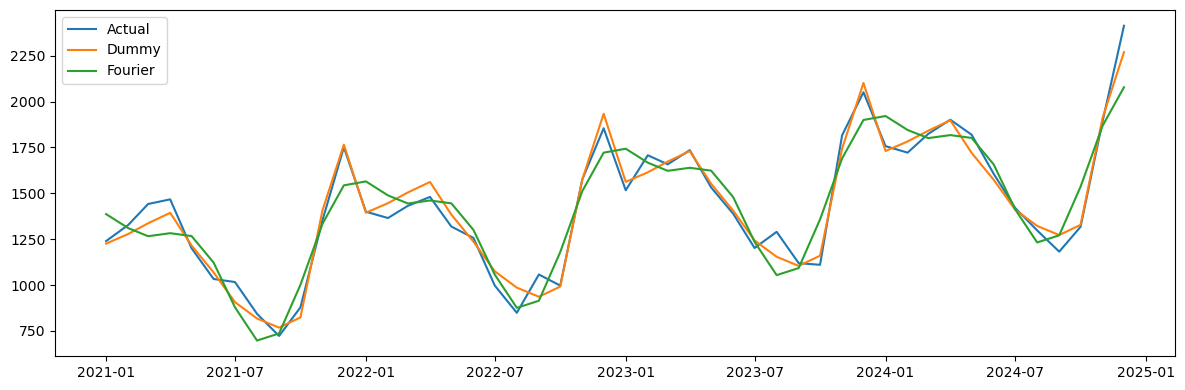

Dummy variable model preferred because it fits the seasonal pattern more precisely.


In [7]:
# --------------------------------------------------------------------
# A3: Fourier Seasonality
# --------------------------------------------------------------------
print("\n" + "-" * 70)
print("A3: Fourier Seasonality")
print("-" * 70)

df_sales['sin1'] = np.sin(2*np.pi*df_sales['Time']/12)
df_sales['cos1'] = np.cos(2*np.pi*df_sales['Time']/12)
df_sales['sin2'] = np.sin(4*np.pi*df_sales['Time']/12)
df_sales['cos2'] = np.cos(4*np.pi*df_sales['Time']/12)

Xf = sm.add_constant(df_sales[['Time','sin1','cos1','sin2','cos2']])
fourier_model = sm.OLS(df_sales['Sales'], Xf).fit()

print("Dummy model AIC:", reg_model.aic)
print("Fourier model AIC:", fourier_model.aic)

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(df_sales.index, df_sales['Sales'], label="Actual")
ax.plot(df_sales.index, reg_model.fittedvalues, label="Dummy")
ax.plot(df_sales.index, fourier_model.fittedvalues, label="Fourier")
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

if fourier_model.aic < reg_model.aic:
    print("Fourier model preferred because it achieves similar fit using fewer parameters.")
else:
    print("Dummy variable model preferred because it fits the seasonal pattern more precisely.")

In [8]:
# --------------------------------------------------------------------
# A4: Simple Exponential Smoothing (SES)
# --------------------------------------------------------------------
print("\n" + "-" * 70)
print("A4: Simple Exponential Smoothing")
print("-" * 70)

train_sales = df_sales['Sales'].iloc[:36]
test_sales = df_sales['Sales'].iloc[36:48]

train_months = df_sales['Month'].iloc[:36]
test_months = df_sales['Month'].iloc[36:48]

seasonal_avg_train = train_sales.groupby(train_months).mean()
train_seasonal = train_months.map(seasonal_avg_train)
test_seasonal = test_months.map(seasonal_avg_train)

train_deseason = train_sales - train_seasonal

ses_fit = SimpleExpSmoothing(train_deseason).fit(optimized=True)
alpha_opt = ses_fit.model.params.get('smoothing_level', None)

print("Optimized α:", alpha_opt)
print("The smoothing parameter indicates how quickly the model reacts to new observations; the series updates gradually rather than abruptly.")

ses_fc_deseason = ses_fit.forecast(12)
ses_fc = ses_fc_deseason + test_seasonal.values
ses_fc = pd.Series(ses_fc.values, index=test_sales.index)

ses_rmse = np.sqrt(np.mean((test_sales - ses_fc)**2))
ses_mae = np.mean(np.abs(test_sales - ses_fc))
print("Forecast accuracy on holdout:")
print("RMSE:", ses_rmse)
print("MAE:", ses_mae)


----------------------------------------------------------------------
A4: Simple Exponential Smoothing
----------------------------------------------------------------------
Optimized α: 0.411156955863119
The smoothing parameter indicates how quickly the model reacts to new observations; the series updates gradually rather than abruptly.
Forecast accuracy on holdout:
RMSE: 186.04910804505758
MAE: 167.26315172197113



----------------------------------------------------------------------
A5: Holt's Method
----------------------------------------------------------------------
Optimized α (level): 0.21816852212232293
Optimized β (trend): 0.0007147393703560681
Final level (ℓ_t): 206.55671952387831
Final trend (b_t): 10.584986680682132


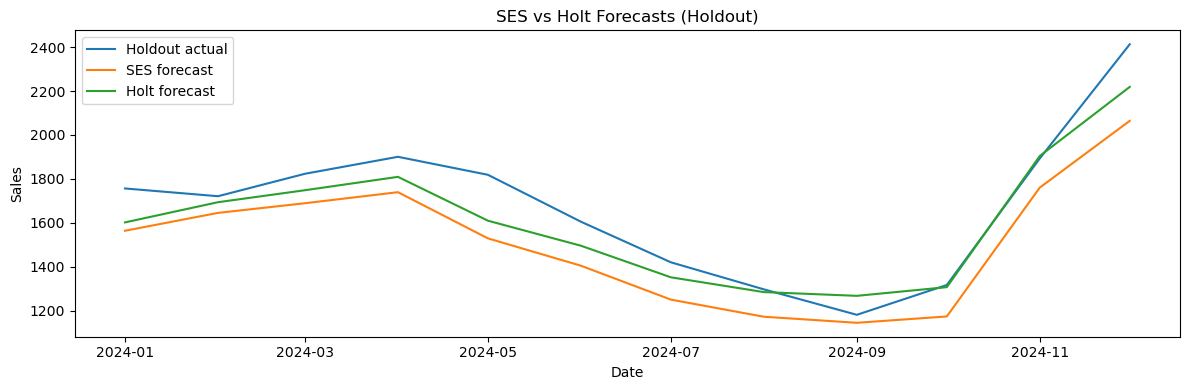

Holt’s method captures the upward trend better because it explicitly models a time trend component.


In [9]:
# --------------------------------------------------------------------
# A5: Holt's Linear Trend Method
# --------------------------------------------------------------------
print("\n" + "-" * 70)
print("A5: Holt's Method")
print("-" * 70)

holt_fit = ExponentialSmoothing(train_deseason, trend='add', seasonal=None).fit(optimized=True)

holt_alpha = holt_fit.model.params.get('smoothing_level', None)
holt_beta = holt_fit.model.params.get('smoothing_trend', None)
print("Optimized α (level):", holt_alpha)
print("Optimized β (trend):", holt_beta)

final_level = holt_fit.level[-1]
final_trend = holt_fit.trend[-1]
print("Final level (ℓ_t):", final_level)
print("Final trend (b_t):", final_trend)

holt_fc_deseason = holt_fit.forecast(12)
holt_fc = holt_fc_deseason + test_seasonal.values
holt_fc = pd.Series(holt_fc.values, index=test_sales.index)

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(test_sales.index, test_sales.values, label="Holdout actual")
ax.plot(ses_fc.index, ses_fc.values, label="SES forecast")
ax.plot(holt_fc.index, holt_fc.values, label="Holt forecast")
ax.set_title("SES vs Holt Forecasts (Holdout)")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

print("Holt’s method captures the upward trend better because it explicitly models a time trend component.")


----------------------------------------------------------------------
A6: Holt-Winters Method
----------------------------------------------------------------------
Optimized α: 0.1994631630106833
Optimized β: 0.17148120663346608
Optimized γ: 0.013728827469655343


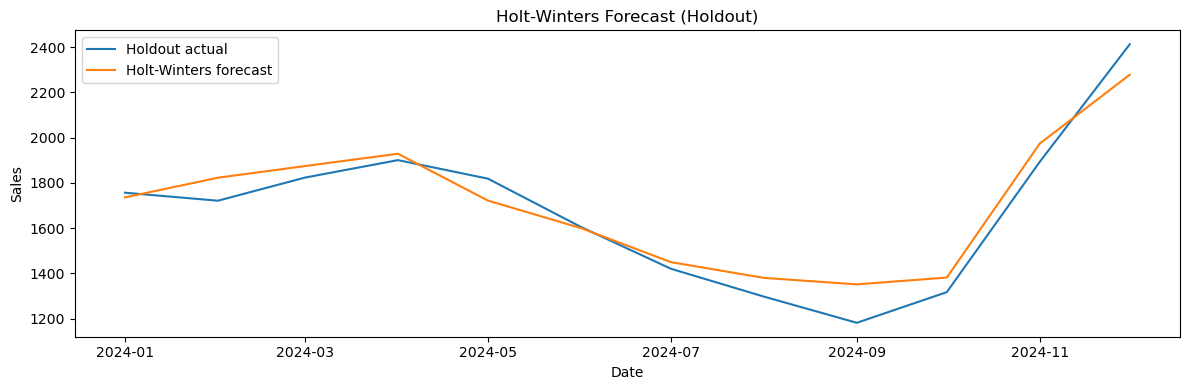

Forecast accuracy on holdout (Holt-Winters):
RMSE: 86.05049061196593
MAE: 72.07612588606308

Compare forecast accuracy (holdout):
Regression RMSE: 85.38714339080131 MAE: 59.75735524739745
SES RMSE: 186.04910804505758 MAE: 167.26315172197113
Holt RMSE: 109.61028689202737 MAE: 87.31901431888286
Holt-Winters RMSE: 86.05049061196593 MAE: 72.07612588606308
Regression gives the lowest holdout error (RMSE and MAE). Holt-Winters is close but not the best for this dataset.


In [10]:
# --------------------------------------------------------------------
# A6: Holt-Winters Seasonal Method
# --------------------------------------------------------------------
print("\n" + "-" * 70)
print("A6: Holt-Winters Method")
print("-" * 70)

hw_fit = ExponentialSmoothing(
    train_sales,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)

hw_alpha = hw_fit.model.params.get('smoothing_level', None)
hw_beta = hw_fit.model.params.get('smoothing_trend', None)
hw_gamma = hw_fit.model.params.get('smoothing_seasonal', None)
print("Optimized α:", hw_alpha)
print("Optimized β:", hw_beta)
print("Optimized γ:", hw_gamma)

hw_fc = hw_fit.forecast(12)

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(test_sales.index, test_sales.values, label="Holdout actual")
ax.plot(hw_fc.index, hw_fc.values, label="Holt-Winters forecast")
ax.set_title("Holt-Winters Forecast (Holdout)")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

hw_rmse = np.sqrt(np.mean((test_sales - hw_fc)**2))
hw_mae = np.mean(np.abs(test_sales - hw_fc))
print("Forecast accuracy on holdout (Holt-Winters):")
print("RMSE:", hw_rmse)
print("MAE:", hw_mae)

# Regression holdout accuracy (fit on first 36, predict next 12)
train_df = df_sales.iloc[:36].copy()
test_df = df_sales.iloc[36:48].copy()

train_dummies = pd.get_dummies(train_df['Month'], drop_first=True, dtype=float)
X_train = pd.concat([train_df['Time'].astype(float), train_dummies], axis=1)
X_train = sm.add_constant(X_train)
y_train = train_df['Sales'].astype(float)
reg_train = sm.OLS(y_train, X_train).fit()

test_dummies = pd.get_dummies(test_df['Month'], drop_first=True, dtype=float)
test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)
X_test = pd.concat([test_df['Time'].astype(float), test_dummies], axis=1)
X_test = sm.add_constant(X_test)
reg_fc = reg_train.predict(X_test)

reg_rmse = np.sqrt(np.mean((test_sales - reg_fc)**2))
reg_mae = np.mean(np.abs(test_sales - reg_fc))

holt_rmse = np.sqrt(np.mean((test_sales - holt_fc)**2))
holt_mae = np.mean(np.abs(test_sales - holt_fc))

print("\nCompare forecast accuracy (holdout):")
print("Regression RMSE:", reg_rmse, "MAE:", reg_mae)
print("SES RMSE:", ses_rmse, "MAE:", ses_mae)
print("Holt RMSE:", holt_rmse, "MAE:", holt_mae)
print("Holt-Winters RMSE:", hw_rmse, "MAE:", hw_mae)

print("Regression gives the lowest holdout error (RMSE and MAE). Holt-Winters is close but not the best for this dataset.")

In [11]:
# ====================================================================
# PART B: ARIMA MODELS
# ====================================================================
print("\n" + "=" * 70)
print("PART B: ARIMA MODELS")
print("=" * 70)


PART B: ARIMA MODELS


In [12]:
# ====================================================================
# DATASET 2: DAILY STOCK RETURNS (for ARIMA)
# ====================================================================
print("\n" + "=" * 70)
print("DATASET 2: Daily Stock Returns")
print("=" * 70)

n_days = 500
dates_stock = pd.date_range('2023-01-01', periods=n_days, freq='D')

returns = np.zeros(n_days)
returns[0] = np.random.normal(0, 0.01)

phi = 0.05
for i in range(1, n_days):
    returns[i] = phi * returns[i-1] + np.random.normal(0, 0.015)

price = 100 * np.exp(np.cumsum(returns))

df_stock = pd.DataFrame({
    'Date': dates_stock,
    'Price': price,
    'Returns': returns * 100
}).set_index('Date')

print(f"Date range: {df_stock.index[0].date()} to {df_stock.index[-1].date()}")
print(f"Number of days: {len(df_stock)}")
print("\nPrice Statistics:")
print(df_stock['Price'].describe())


DATASET 2: Daily Stock Returns
Date range: 2023-01-01 to 2024-05-14
Number of days: 500

Price Statistics:
count    500.000000
mean     115.002874
std       12.793924
min       94.210519
25%      102.898666
50%      115.340500
75%      125.312316
max      149.153080
Name: Price, dtype: float64



----------------------------------------------------------------------
B1: Stationarity Tests
----------------------------------------------------------------------


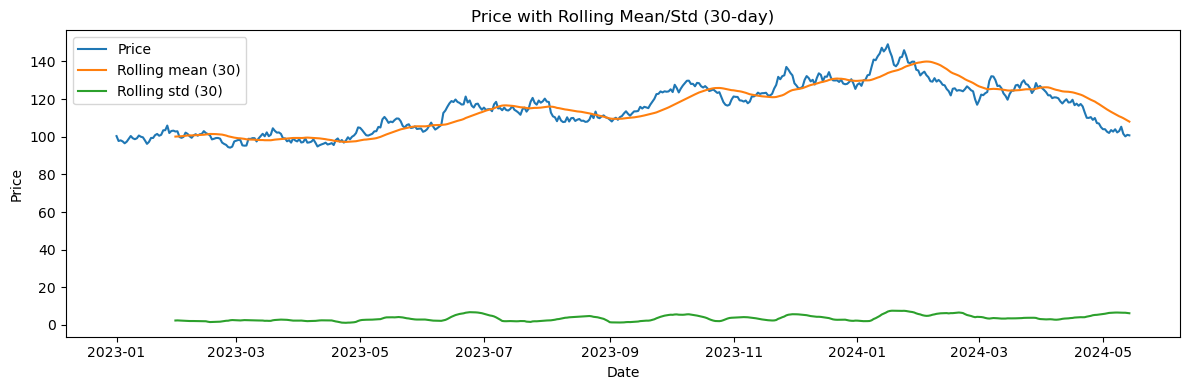

ADF p-value: 0.5243213458211402
KPSS p-value: 0.01
ADF fails to reject a unit root while KPSS rejects stationarity. This indicates stock prices follow a random walk and are non-stationary.


In [13]:
# --------------------------------------------------------------------
# B1: Stationarity Testing
# --------------------------------------------------------------------
print("\n" + "-" * 70)
print("B1: Stationarity Tests")
print("-" * 70)

roll_mean = df_stock['Price'].rolling(30).mean()
roll_std = df_stock['Price'].rolling(30).std()

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(df_stock.index, df_stock['Price'], label='Price')
ax.plot(df_stock.index, roll_mean, label='Rolling mean (30)')
ax.plot(df_stock.index, roll_std, label='Rolling std (30)')
ax.set_title("Price with Rolling Mean/Std (30-day)")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

adf_stat, adf_p, _, _, _, _ = adfuller(df_stock['Price'])
kpss_stat, kpss_p, _, _ = kpss(df_stock['Price'], regression='c', nlags='auto')

print("ADF p-value:", adf_p)
print("KPSS p-value:", kpss_p)

print("ADF fails to reject a unit root while KPSS rejects stationarity. This indicates stock prices follow a random walk and are non-stationary.")


----------------------------------------------------------------------
B2: Differencing for Stationarity
----------------------------------------------------------------------


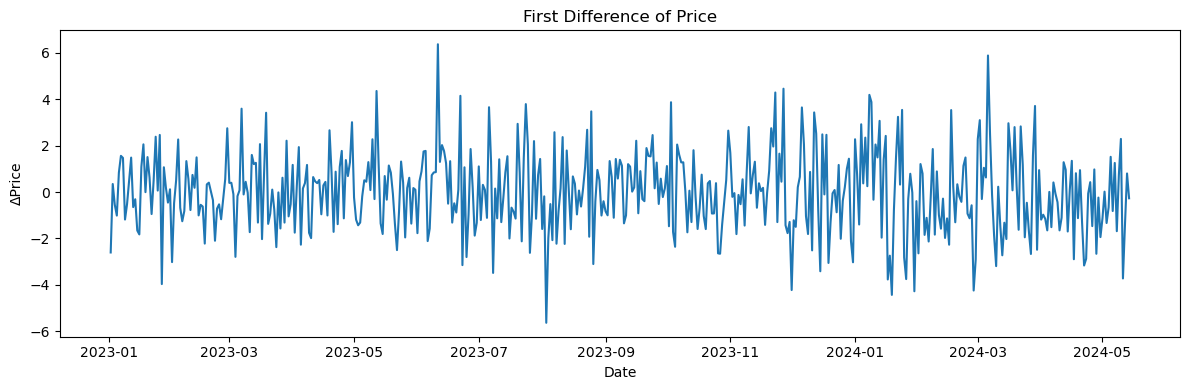

ADF test statistic (differenced): -21.40862857507445
ADF p-value (differenced): 0.0
ADF rejects the unit root after differencing → the series is stationary.
Correlation between ΔPrice and Returns: 0.9937385243812942


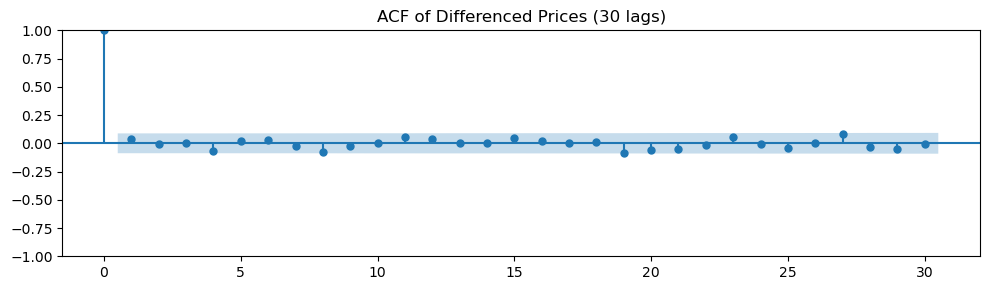

In [14]:
# ================================================================
# B2: First Differencing
# ================================================================
print("\n" + "-" * 70)
print("B2: Differencing for Stationarity")
print("-" * 70)

# First difference of price
diff_price = df_stock['Price'].diff().dropna()

# Plot differenced series
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(diff_price.index, diff_price.values)
ax.set_title("First Difference of Price")
ax.set_xlabel("Date")
ax.set_ylabel("ΔPrice")
plt.tight_layout()
plt.show()
plt.close(fig)

# ADF test on differenced series
adf_stat_d, adf_p_d, _, _, _, _ = adfuller(diff_price)

print("ADF test statistic (differenced):", adf_stat_d)
print("ADF p-value (differenced):", adf_p_d)

if adf_p_d < 0.05:
    print("ADF rejects the unit root after differencing → the series is stationary.")
else:
    print("ADF fails to reject the unit root → the series is still non-stationary.")

# Compare with returns
returns_aligned = df_stock['Returns'].iloc[1:]
corr = np.corrcoef(diff_price.values, returns_aligned.values)[0,1]
print("Correlation between ΔPrice and Returns:", corr)

# ACF of differenced prices
fig, ax = plt.subplots(figsize=(10,3))
plot_acf(diff_price, lags=30, ax=ax)
ax.set_title("ACF of Differenced Prices (30 lags)")
plt.tight_layout()
plt.show()
plt.close(fig)


----------------------------------------------------------------------
B3: ACF and PACF
----------------------------------------------------------------------


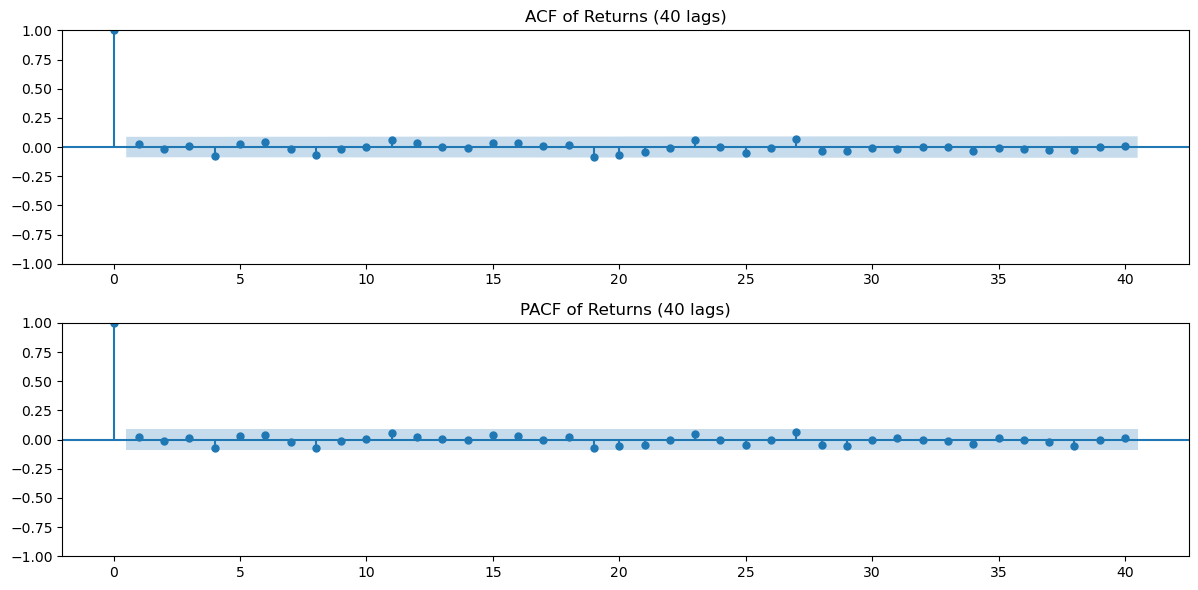

rho(1): 0.023787313738389486
rho(5): 0.0272537890174487
ACF and PACF show no meaningful autocorrelation at the inspected lags, so returns behave approximately as white noise.
A low-order AR or MA model (or no ARMA structure) is appropriate.


In [15]:
# ================================================================
# B3: ACF and PACF Analysis
# ================================================================
print("\n" + "-" * 70)
print("B3: ACF and PACF")
print("-" * 70)

r = df_stock['Returns'].dropna()

# ACF + PACF plots
fig, ax = plt.subplots(2, 1, figsize=(12,6))
plot_acf(r, lags=40, ax=ax[0])
ax[0].set_title("ACF of Returns (40 lags)")
plot_pacf(r, lags=40, ax=ax[1], method='ywm')
ax[1].set_title("PACF of Returns (40 lags)")
plt.tight_layout()
plt.show()
plt.close(fig)

# Manual autocorrelations
rho1 = np.corrcoef(r.values[1:], r.values[:-1])[0,1]
rho5 = np.corrcoef(r.values[5:], r.values[:-5])[0,1]
print("rho(1):", rho1)
print("rho(5):", rho5)

# Interpretation
print("ACF and PACF show no meaningful autocorrelation at the inspected lags, so returns behave approximately as white noise.")
print("A low-order AR or MA model (or no ARMA structure) is appropriate.")


----------------------------------------------------------------------
B4: AR(p) Model
----------------------------------------------------------------------
                               SARIMAX Results                                
Dep. Variable:                Returns   No. Observations:                  500
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -902.468
Date:                Thu, 12 Feb 2026   AIC                           1810.936
Time:                        14:18:26   BIC                           1823.579
Sample:                    01-01-2023   HQIC                          1815.897
                         - 05-14-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015      0.068      0.022      0.

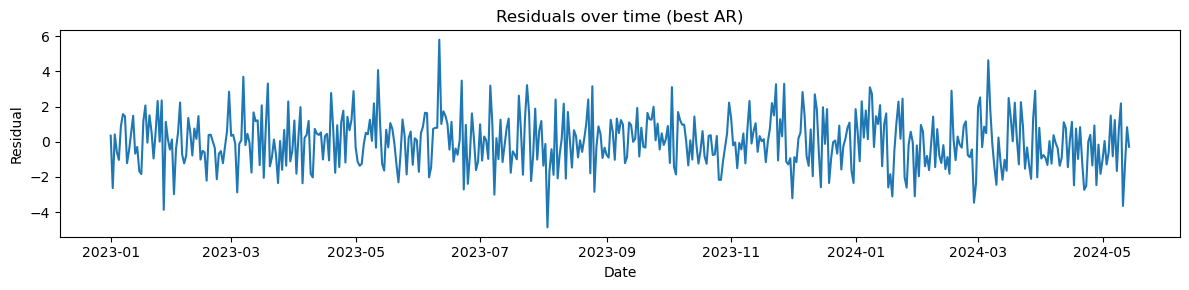

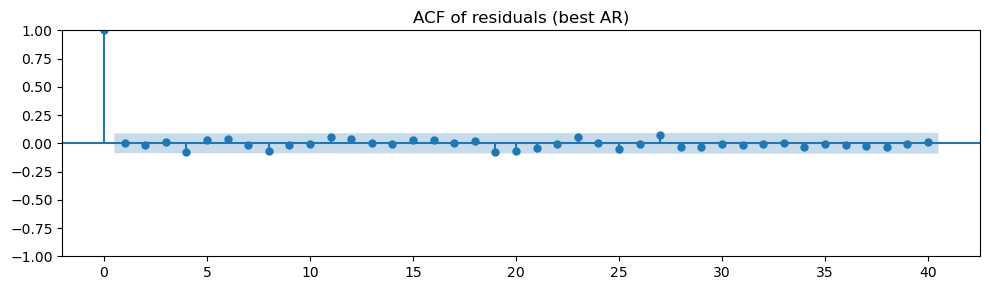

If residual ACF shows no significant spikes, residuals are approximately white noise and the model is adequate.


In [16]:
# ================================================================
# B4: AR Model Estimation
# ================================================================
print("\n" + "-" * 70)
print("B4: AR(p) Model")
print("-" * 70)

r = df_stock['Returns'].dropna()

# AR(1)
ar1 = ARIMA(r, order=(1,0,0)).fit()
print(ar1.summary().tables[0])
print(ar1.summary().tables[1])

phi1 = ar1.params.get('ar.L1', np.nan)
phi1_p = ar1.pvalues.get('ar.L1', np.nan)
print("\nphi1:", phi1, "p-value:", phi1_p)
print("Stationarity condition |phi1| < 1:", bool(np.abs(phi1) < 1))

if np.isfinite(phi1_p) and phi1_p < 0.05:
    print("AR(1) term is significant → some predictability from lagged returns.")
else:
    print("AR(1) term is not significant → past returns do not predict future returns.")

# AR(2) and AR(3) for AIC comparison
ar2 = ARIMA(r, order=(2,0,0)).fit()
ar3 = ARIMA(r, order=(3,0,0)).fit()

print("\nAIC AR(1):", ar1.aic)
print("AIC AR(2):", ar2.aic)
print("AIC AR(3):", ar3.aic)

best_ar = min([(ar1.aic, ar1, "AR(1)"), (ar2.aic, ar2, "AR(2)"), (ar3.aic, ar3, "AR(3)")], key=lambda x: x[0])
best_ar_model = best_ar[1]
print("Preferred model by AIC:", best_ar[2])

# Residual diagnostics
resid = best_ar_model.resid

fig, ax = plt.subplots(figsize=(12,3))
ax.plot(resid.index, resid.values)
ax.set_title("Residuals over time (best AR)")
ax.set_xlabel("Date")
ax.set_ylabel("Residual")
plt.tight_layout()
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(10,3))
plot_acf(resid, lags=40, ax=ax)
ax.set_title("ACF of residuals (best AR)")
plt.tight_layout()
plt.show()
plt.close(fig)

print("If residual ACF shows no significant spikes, residuals are approximately white noise and the model is adequate.")


----------------------------------------------------------------------
B5: MA(q) Model
----------------------------------------------------------------------
                               SARIMAX Results                                
Dep. Variable:                Returns   No. Observations:                  500
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -902.464
Date:                Thu, 12 Feb 2026   AIC                           1810.928
Time:                        14:18:26   BIC                           1823.572
Sample:                    01-01-2023   HQIC                          1815.889
                         - 05-14-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015      0.068      0.022      0.

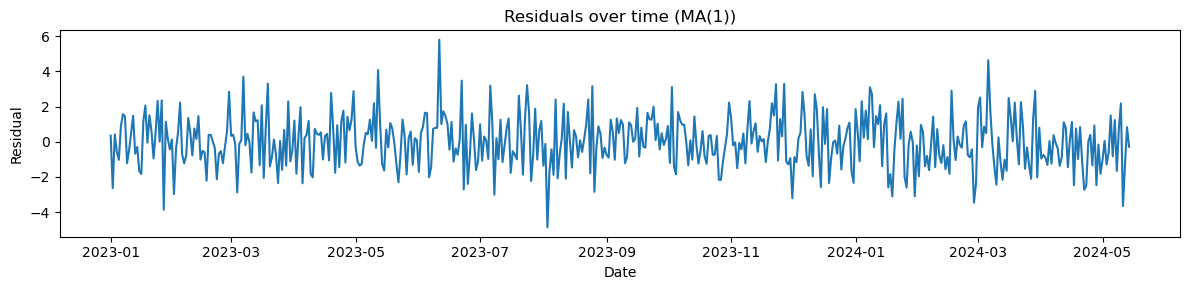

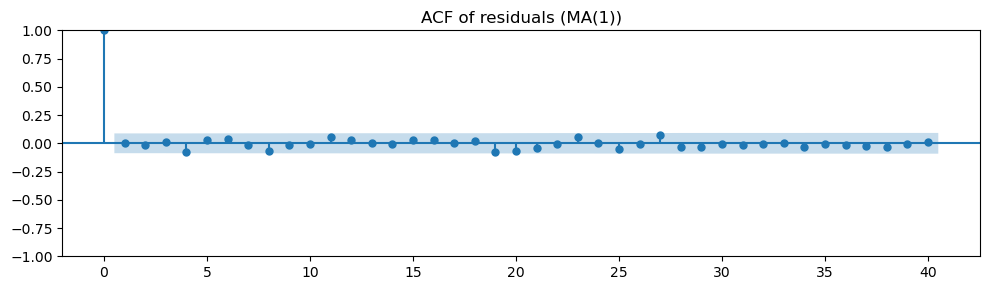

If residual ACF shows no significant spikes, residuals are approximately white noise and the model is adequate.


In [17]:
# ================================================================
# B5: MA Model Estimation
# ================================================================
print("\n" + "-" * 70)
print("B5: MA(q) Model")
print("-" * 70)

r = df_stock['Returns'].dropna()

# MA(1)
ma1 = ARIMA(r, order=(0,0,1)).fit()
print(ma1.summary().tables[0])
print(ma1.summary().tables[1])

theta1 = ma1.params.get('ma.L1', np.nan)
theta1_p = ma1.pvalues.get('ma.L1', np.nan)
print("\ntheta1:", theta1, "p-value:", theta1_p)
print("Invertibility |theta1| < 1:", bool(np.abs(theta1) < 1))

if np.isfinite(theta1_p) and theta1_p < 0.05:
    print("MA(1) term is significant → shocks have short-run effect.")
else:
    print("MA(1) term is not significant → returns behave close to white noise.")

# Compare MA(1) vs AR(1)
print("\nCompare MA(1) vs AR(1):")
print("AR(1) AIC:", ar1.aic, "BIC:", ar1.bic, "LogLik:", ar1.llf)
print("MA(1) AIC:", ma1.aic, "BIC:", ma1.bic, "LogLik:", ma1.llf)

# Residual diagnostics
resid_ma = ma1.resid

fig, ax = plt.subplots(figsize=(12,3))
ax.plot(resid_ma.index, resid_ma.values)
ax.set_title("Residuals over time (MA(1))")
ax.set_xlabel("Date")
ax.set_ylabel("Residual")
plt.tight_layout()
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(10,3))
plot_acf(resid_ma, lags=40, ax=ax)
ax.set_title("ACF of residuals (MA(1))")
plt.tight_layout()
plt.show()
plt.close(fig)

print("If residual ACF shows no significant spikes, residuals are approximately white noise and the model is adequate.")

In [18]:
# ================================================================
# B6: ARMA(p,q) Model
# ================================================================
print("\n" + "-" * 70)
print("B6: ARMA(p,q) Model")
print("-" * 70)

r = df_stock['Returns'].dropna()

# ARMA(1,1)
arma11 = ARIMA(r, order=(1,0,1)).fit()
print(arma11.summary().tables[0])
print(arma11.summary().tables[1])

# Compare with AR(1) and MA(1)
comp = pd.DataFrame({
    'Model': ['AR(1)', 'MA(1)', 'ARMA(1,1)'],
    'AIC': [ar1.aic, ma1.aic, arma11.aic],
    'BIC': [ar1.bic, ma1.bic, arma11.bic],
    'Log-Lik': [ar1.llf, ma1.llf, arma11.llf],
    'Parameters': [len(ar1.params), len(ma1.params), len(arma11.params)]
})
print("\n", comp)

print("Model choice: prefer the model with the lowest AIC/BIC. If ARMA(1,1) does not improve AIC/BIC, a simpler model is preferred.")


----------------------------------------------------------------------
B6: ARMA(p,q) Model
----------------------------------------------------------------------
                               SARIMAX Results                                
Dep. Variable:                Returns   No. Observations:                  500
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -901.801
Date:                Thu, 12 Feb 2026   AIC                           1811.602
Time:                        14:18:26   BIC                           1828.461
Sample:                    01-01-2023   HQIC                          1818.217
                         - 05-14-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015      0.068      0.022    

In [19]:
# ================================================================
# B7: Automatic ARIMA Selection
# ================================================================
print("\n" + "-" * 70)
print("B7: Automatic ARIMA")
print("-" * 70)

r = df_stock['Returns'].dropna()

best_aic = np.inf
best_order = None
best_fit = None

for p in range(6):
    for q in range(6):
        try:
            fit = ARIMA(r, order=(p,0,q)).fit()
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_order = (p,0,q)
                best_fit = fit
        except:
            continue

print("Best model specification:", best_order)
print("Best AIC:", best_aic)
print(best_fit.summary().tables[0])
print(best_fit.summary().tables[1])

print("Interpretation: selecting ARIMA(0,0,0) implies returns behave like white noise (no predictable AR/MA structure).")


----------------------------------------------------------------------
B7: Automatic ARIMA
----------------------------------------------------------------------
Best model specification: (0, 0, 0)
Best AIC: 1809.2180830226218
                               SARIMAX Results                                
Dep. Variable:                Returns   No. Observations:                  500
Model:                          ARIMA   Log Likelihood                -902.609
Date:                Thu, 12 Feb 2026   AIC                           1809.218
Time:                        14:18:33   BIC                           1817.647
Sample:                    01-01-2023   HQIC                          1812.526
                         - 05-14-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------


----------------------------------------------------------------------
B8: ARIMA Forecasting
----------------------------------------------------------------------


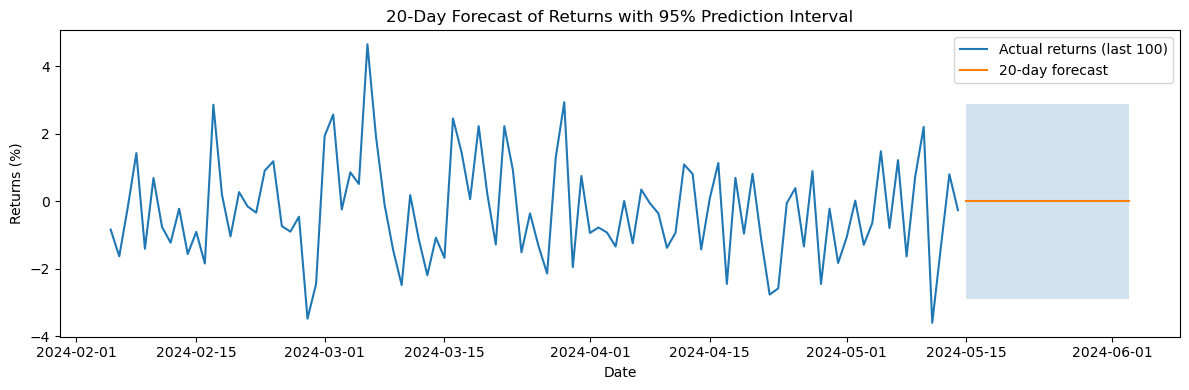

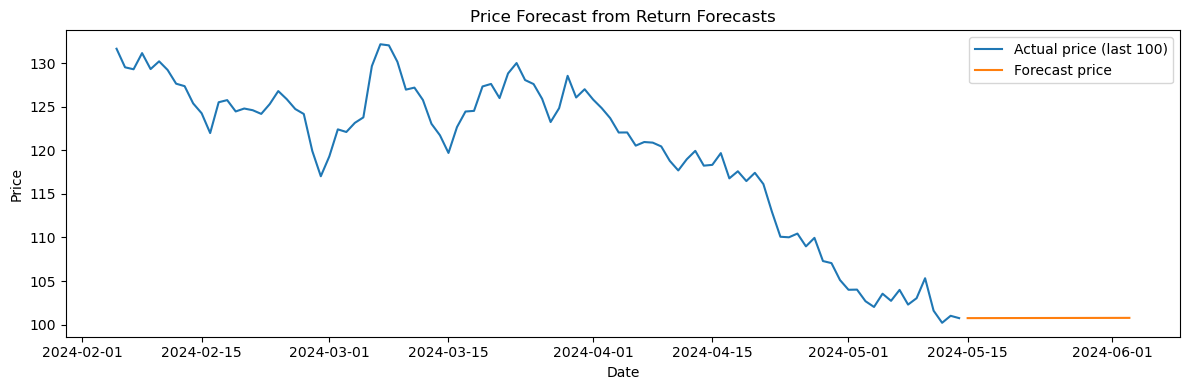

Return forecasts converge toward zero because returns have approximately zero mean and little autocorrelation (consistent with efficient markets).
Prediction intervals widen with horizon because forecast uncertainty accumulates over time.


In [20]:
# ================================================================
# B8: ARIMA Forecasting
# ================================================================
print("\n" + "-" * 70)
print("B8: ARIMA Forecasting")
print("-" * 70)

r = df_stock['Returns'].dropna()

# Fit best model from B7
model = ARIMA(r, order=best_order).fit()

fc = model.get_forecast(steps=20)
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int(alpha=0.05)

# Plot: last 100 returns + 20-step forecast + 95% interval
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(r.iloc[-100:].index, r.iloc[-100:].values, label="Actual returns (last 100)")
ax.plot(fc_mean.index, fc_mean.values, label="20-day forecast")
ax.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], alpha=0.2)
ax.set_title("20-Day Forecast of Returns with 95% Prediction Interval")
ax.set_xlabel("Date")
ax.set_ylabel("Returns (%)")
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

# Convert return forecasts to price forecasts
last_price = df_stock['Price'].iloc[-1]
ret_dec = fc_mean.values / 100.0
price_fc = last_price * np.exp(np.cumsum(ret_dec))
price_fc = pd.Series(price_fc, index=fc_mean.index)

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(df_stock['Price'].iloc[-100:].index, df_stock['Price'].iloc[-100:].values, label="Actual price (last 100)")
ax.plot(price_fc.index, price_fc.values, label="Forecast price")
ax.set_title("Price Forecast from Return Forecasts")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

print("Return forecasts converge toward zero because returns have approximately zero mean and little autocorrelation (consistent with efficient markets).")
print("Prediction intervals widen with horizon because forecast uncertainty accumulates over time.")